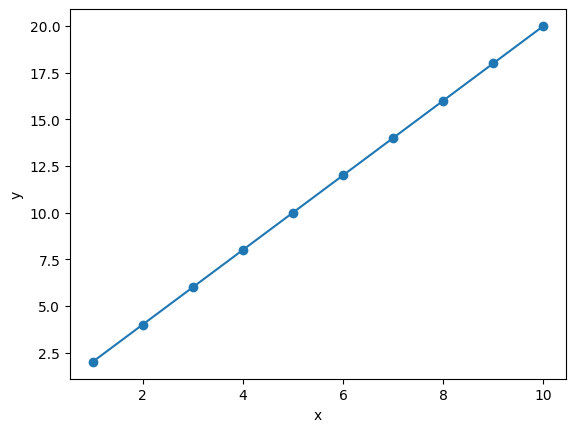

Regression Coefficients:  2.0  and  0.0
p-value=  4.375000000000076e-80
R2 Score=  1.0
Standard Error=  0.0
Equation of line:
y= 2.0 x + 0.0 + 0.0
For x=11, y= 22.0


In [ ]:
#Linear Regression

import matplotlib.pyplot as plt
from scipy import stats
x = [1,2,3,4,5,6,7,8,9,10]
y = [2,4,6,8,10,12,14,16,18,20]
slope, intercept, r, p, std_err = stats.linregress(x, y)
def myfunc(x):
    return slope * x + intercept
mymodel = list(map(myfunc, x))
plt.scatter(x, y)
plt.plot(x, mymodel)
plt.xlabel("x")
plt.ylabel("y")
plt.show()
print("Regression Coefficients: ", slope, " and ", intercept)
print("p-value= ",p)
print("R2 Score= ",r)
print("Standard Error= ",std_err)
print("Equation of line:")
print("y=",round(slope,2),"x","+",round(intercept,2),"+",round(std_err,0))
print("For x=11, y=",myfunc(11))

In [ ]:
import pandas as pd
df=pd.read_csv("Housing(1).csv",index_col=None)
print(df)

        price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       no   

    hotwaterheating aircond

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
print(df.describe())

              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


<Axes: >

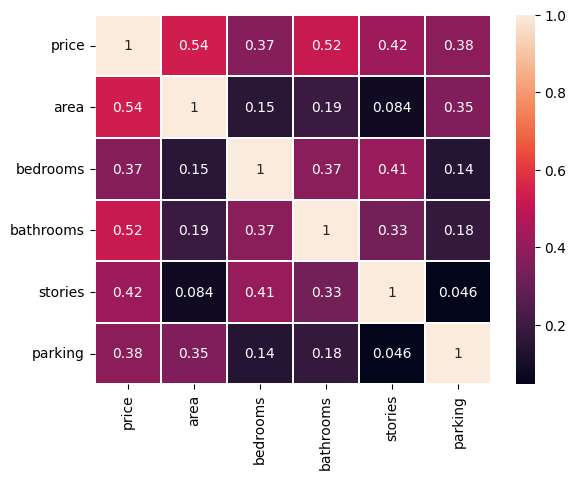

In [ ]:
#Plot heatmap of correlation matrix
import seaborn as sns
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(data=numeric_df.corr(), annot=True, linecolor='white', linewidths=0.25)

In [ ]:
y

[2, 4, 6, 8, 10, 12, 14, 16, 18, 20]

In [ ]:
x

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(x,y,random_state=42,train_size=0.7)

In [ ]:
#Linear Regression
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Reshape X_train and y_train to 2D arrays
X_train_reshaped = np.array(X_train).reshape(-1, 1)
y_train_reshaped = np.array(y_train).reshape(-1, 1)

reg = LinearRegression().fit(X_train_reshaped, y_train_reshaped)
print("Regression Coefficient=",reg.coef_)
print("Regression Intercept=",reg.intercept_)
print("Mean Absolute Error=",mean_absolute_error(y_train_reshaped, reg.predict(X_train_reshaped)))
print("Mean Squared Error=",mean_squared_error(y_train_reshaped, reg.predict(X_train_reshaped)))
print("Root Mean Squared Error=",np.sqrt(mean_squared_error(y_train_reshaped, reg.predict(X_train_reshaped))))
print("R2 Score=",reg.score(X_train_reshaped, y_train_reshaped))

Regression Coefficient= [[2.]]
Regression Intercept= [-5.32907052e-15]
Mean Absolute Error= 1.7763568394002505e-15
Mean Squared Error= 5.183943091452363e-30
Root Mean Squared Error= 2.2768274180210415e-15
R2 Score= 1.0


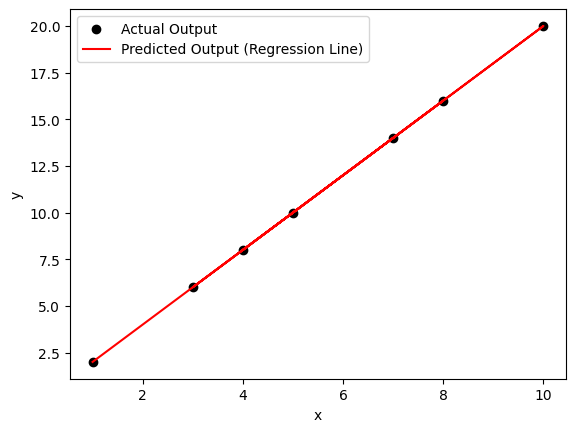

In [ ]:
import numpy as np
plt.scatter(X_train, y_train,color='black')
# Reshape X_train for prediction, as the model was trained on reshaped data
X_train_for_prediction = np.array(X_train).reshape(-1, 1)
plt.plot(X_train, reg.predict(X_train_for_prediction),color='red')
plt.xlabel("x")
plt.ylabel("y")
plt.legend(["Actual Output", "Predicted Output (Regression Line)"], loc="upper left")
plt.show()

Actual Output= [14, 22, 24, 32, 36, 41, 44, 52]
Predicted Output= [15.16666667 20.29761905 25.42857143 30.55952381 35.69047619 40.82142857
 45.95238095 51.08333333]
Regression Coefficient= [5.13095238]
Regression Intercept= 10.035714285714281
Mean Absolute Error= 1.1369047619047623
Mean Squared Error= 1.6443452380952412
Root Mean Squared Error= 1.2823202556675306
R2 Score= 0.9882428672507994


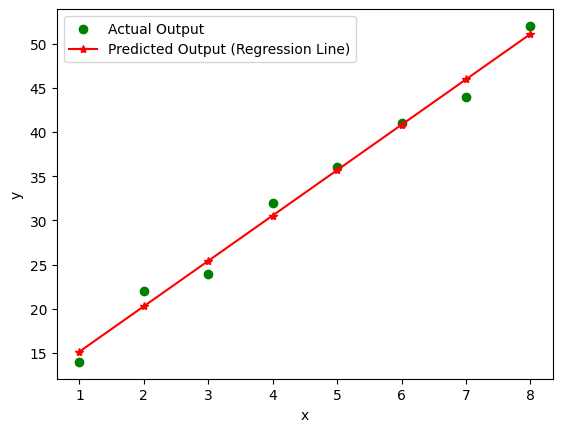

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
X=[[1],[2],[3],[4],[5],[6],[7],[8]]
y=[14,22,24,32,36,41,44,52]
reg = LinearRegression().fit(X, y)
print("Actual Output=",y)
print("Predicted Output=",reg.predict(X))
print("Regression Coefficient=",reg.coef_)
print("Regression Intercept=",reg.intercept_)
print("Mean Absolute Error=",mean_absolute_error(y, reg.predict(X)))
print("Mean Squared Error=",mean_squared_error(y, reg.predict(X)))
print("Root Mean Squared Error=",np.sqrt(mean_squared_error(y, reg.predict(X))))
print("R2 Score=",reg.score(X, y))
plt.scatter(X, y,color='green')
plt.plot(X, reg.predict(X),color='red', marker='*')
plt.xlabel("x")
plt.ylabel("y")
plt.legend(["Actual Output", "Predicted Output (Regression Line)"], loc="upper left")
plt.show()